In [1]:
import os
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

os.environ["MUJOCO_GL"] = "egl"

repo_root = Path("/home/helix/projects/METRA-Projects/FlashSAC")
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from flash_rl.agents.metra.agent import METRAAgent
from flash_rl.agents.metra.sampler import Sampler
from flash_rl.envs.envs.mujoco.ant_env import AntEnv

@dataclass
class Config:
    skill_dim: int = 2
    model_master_dim: int = 1024
    model_master_num_layers: int = 2
    spectral_normalization: bool = False
    dual_lam: float = 30.0
    alpha: float = 0.01
    common_lr: float = 1e-4
    gamma: float = 0.99
    buffer_max_length: int = 300000
    buffer_min_length: int = 10000
    sample_batch_size: int = 256
    target_coef: float = 1.0
    dual_slack: float = 1e-3
    discount: float = 0.99
    tau: float = 0.005

cfg = Config()

def _latest_checkpoint_path(root: Path) -> Path:
    run_dirs = sorted([path for path in root.glob("seed*") if path.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    latest_run = run_dirs[-1]
    checkpoint_paths = sorted(
        latest_run.glob("epoch*/agent_state.pt"),
        key=lambda path: int(path.parent.name.replace("epoch", "")),
    )
    if not checkpoint_paths:
        raise FileNotFoundError(f"No checkpoints found under {latest_run}")
    return checkpoint_paths[-1]

checkpoint_root = repo_root / "models" / "general" / "general_train"
checkpoint_path = _latest_checkpoint_path(checkpoint_root)
print(f"Using checkpoint: {checkpoint_path}")

Using checkpoint: /home/helix/projects/METRA-Projects/FlashSAC/models/general/general_train/seed511527-0529-145128/epoch5000/agent_state.pt


In [2]:
env = AntEnv(render_hw=100)
agent = METRAAgent(env, cfg)

checkpoint = torch.load(checkpoint_path, map_location=agent.device)
agent.option_policy.load_state_dict(checkpoint["option_policy_state_dict"])
agent.qf1.load_state_dict(checkpoint["qf1_state_dict"])
agent.qf2.load_state_dict(checkpoint["qf2_state_dict"])
agent.target_qf1.load_state_dict(checkpoint["target_qf1_state_dict"])
agent.target_qf2.load_state_dict(checkpoint["target_qf2_state_dict"])
agent.skill_encoder.load_state_dict(checkpoint["skill_encoder_state_dict"])
agent.dual_lam.load_state_dict(checkpoint["dual_lam_state_dict"])
agent.log_alpha.load_state_dict(checkpoint["log_alpha_state_dict"])

agent.option_policy.eval()
agent.qf1.eval()
agent.qf2.eval()
agent.target_qf1.eval()
agent.target_qf2.eval()
agent.skill_encoder.eval()

sampler = Sampler(env=env, skill_dim=cfg.skill_dim)
print(f"Loaded epoch: {checkpoint['epoch']}")
print(f"Loaded update step: {checkpoint['global_update_step']}")

Loaded epoch: 5000
Loaded update step: 250000


In [3]:
def rollout_paths(policy, sampler, num_paths=8, path_len=200):
    paths = []
    for _ in range(num_paths):
        path = sampler.rollout(policy, path_len=path_len, training=False)
        coords = path["observation"].detach().cpu().numpy()[:, :2]
        skill = path["skill"][0].detach().cpu().numpy()
        paths.append({
            "coords": coords,
            "skill": skill,
        })
    return paths

def plot_xy_rollouts(paths):
    plt.figure(figsize=(8, 8))
    cmap = plt.cm.get_cmap("tab10", len(paths))

    for idx, path in enumerate(paths):
        coords = path["coords"]
        skill = path["skill"]
        color = cmap(idx)

        plt.plot(coords[:, 0], coords[:, 1], color=color, linewidth=1.8, label=f"rollout {idx + 1}")
        plt.scatter(coords[0, 0], coords[0, 1], color=color, s=35, marker="o")
        plt.scatter(coords[-1, 0], coords[-1, 1], color=color, s=45, marker="x")

        displacement_scale = max(np.linalg.norm(coords[-1] - coords[0]), 0.2)
        skill_dir = skill / (np.linalg.norm(skill) + 1e-8)
        skill_arrow = skill_dir * displacement_scale * 0.35
        plt.arrow(
            coords[0, 0],
            coords[0, 1],
            skill_arrow[0],
            skill_arrow[1],
            color=color,
            width=0.002,
            head_width=0.04,
            length_includes_head=True,
            alpha=0.8,
        )

    plt.title("8 Random-Skill Rollout XY Trajectories")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2023056/3170055318.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(paths))


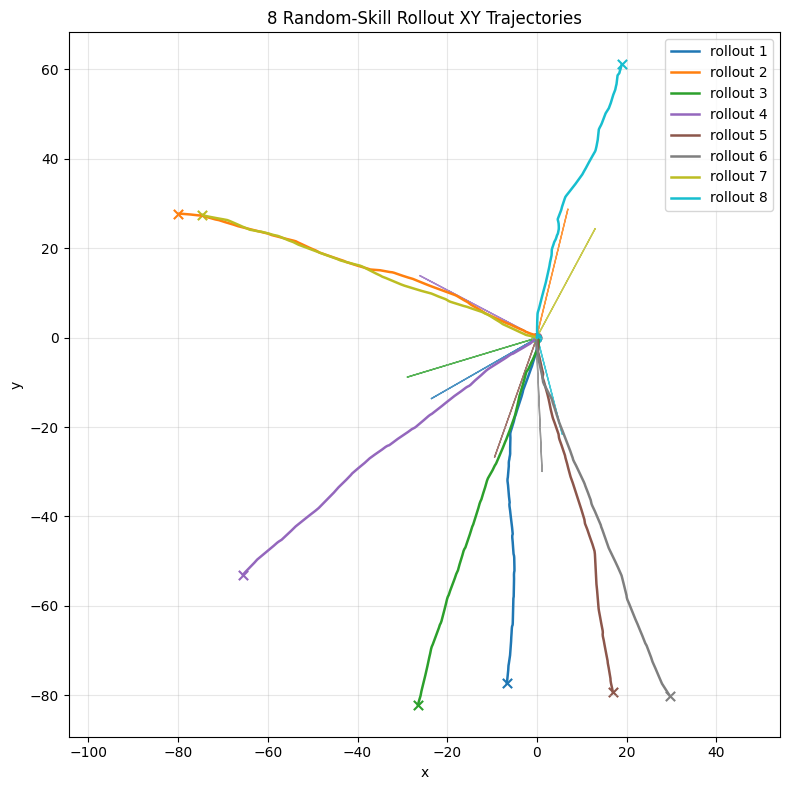

rollout 1: skill=[-0.8671953 -0.4979682], displacement=[ -6.6218185 -77.194145 ]
rollout 2: skill=[0.23676908 0.97156596], displacement=[-79.856186  27.620018]
rollout 3: skill=[-0.9569231 -0.2903412], displacement=[-26.416643 -82.03803 ]
rollout 4: skill=[-0.8841934   0.46712095], displacement=[-65.51716  -53.160812]
rollout 5: skill=[-0.33223644 -0.9431962 ], displacement=[ 16.964708 -79.144005]
rollout 6: skill=[ 0.04333366 -0.9990607 ], displacement=[ 29.843126 -80.16218 ]
rollout 7: skill=[0.47208038 0.8815555 ], displacement=[-74.509346  27.571167]
rollout 8: skill=[ 0.2495299  -0.96836716], displacement=[18.82852 61.14215]


In [5]:
paths = rollout_paths(agent.option_policy, sampler, num_paths=8, path_len=200)
plot_xy_rollouts(paths)

for idx, path in enumerate(paths, start=1):
    displacement = path["coords"][-1] - path["coords"][0]
    print(f"rollout {idx}: skill={path['skill']}, displacement={displacement}")